# Static-field Ramsey RF far frequency scan

This notebook mirrors the wide RF-frequency scan from `far_frequency_fringes.ipynb`, but with a **static DC electric field** of `30 kV/cm` everywhere along the trajectory while keeping the magnetic RF coil envelopes unchanged.

The workflow is:
1. calibrate the second-coil phase `phi2` at resonance in the static-field geometry using a **parallel** `phi2` scan,
2. choose the `phi2` working point that gives survival closest to `0.5`, and
3. run the wide detuning scan with that calibrated phase using the same multiprocessing path as `resonance_frequency_investigation.ipynb`.

The static-field run uses the **dressed state at the actual start field** as the propagated initial state. That is the natural choice for a trajectory which starts directly inside the constant `30 kV/cm` field.

In [6]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# Make the local benchmarks/ package importable whether the notebook is
# opened from the repo root or from examples/ramsey_rf/.
_here = Path.cwd()
for _root in [_here, _here / "examples" / "ramsey_rf", _here.parent]:
    if (_root / "benchmarks" / "run_v3b_cpu_scans.py").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        _BENCH_ROOT = _root
        break
else:
    raise RuntimeError("Could not locate examples/ramsey_rf/benchmarks/")

from centrex_tlf.hamiltonian import generate_uncoupled_hamiltonian_X  # noqa: E402
from benchmarks.reference import E_HIGH, F_RES, build_reference_config  # noqa: E402
from benchmarks.run_v3b_cpu_scans import (  # noqa: E402
    BASIS_DT_US_DEFAULT,
    FRINGE_HZ,
    K_DEFAULT,
    run_frequency_scan_with_phases,
    run_phi2_scan_at_frequency,
)

plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

In [7]:
# Static-field geometry + scan settings.
STATIC_E_FIELD = E_HIGH  # V/cm, use 30 kV/cm everywhere
INITIAL_STATE_MODE = "dressed_start"
REFERENCE_F_RES = F_RES  # legacy resonance used in the plateau notebook

K = K_DEFAULT  # truncated subspace size (24)
BASIS_DT_US = BASIS_DT_US_DEFAULT  # tracked-basis grid (10 us)
N_WORKERS = 8  # process-pool workers

MEAN_VELOCITY = 184.0  # m/s
PHI1 = 0.0  # first coil phase, fixed
TARGET_SURVIVAL = 0.5  # desired Ramsey working point at resonance
N_PHI2 = 17  # phase grid for the resonance calibration

N_FREQ = 161  # points in the far-detuned frequency scan
FRINGES_WINDOW = 10.0  # +/- this many fringe spacings around resonance

PHI2_CACHE_VERSION = 2
FAR_CACHE_VERSION = 2
CACHE_DIR = _BENCH_ROOT / "benchmarks" / "_cache"
PHI2_CACHE = CACHE_DIR / "static30kv_phi2_scan_at_branch_resonance_k24_basis10_v2.npz"
FAR_CACHE = CACHE_DIR / "static30kv_far_frequency_scan_branch_resonance_k24_basis10_v2.npz"

print(f"Static Ez        = {STATIC_E_FIELD * 1e-3:.3f} kV/cm")
print(f"Reference F_RES  = {REFERENCE_F_RES * 1e-3:.3f} kHz")
print(f"fringe spacing   = {FRINGE_HZ:.3f} Hz")
print(f"velocity         = {MEAN_VELOCITY:.1f} m/s")
print(f"parallel workers = {N_WORKERS}")
print(f"phi2 cache       = {PHI2_CACHE.name}")
print(f"far-scan cache   = {FAR_CACHE.name}")

Static Ez        = 30.000 kV/cm
Reference F_RES  = 119.640 kHz
fringe spacing   = 73.600 Hz
velocity         = 184.0 m/s
parallel workers = 8
phi2 cache       = static30kv_phi2_scan_at_branch_resonance_k24_basis10_v2.npz
far-scan cache   = static30kv_far_frequency_scan_branch_resonance_k24_basis10_v2.npz


In [ ]:
from centrex_tlf.states import ElectronicState, UncoupledBasisState  # noqa: E402

from ramsey_rf import adiabatic_branch_to_field, build_basis, build_H_func  # noqa: E402


def _load_valid_cache(path: Path, version: int):
    if not path.exists():
        return None
    data = dict(np.load(path, allow_pickle=False))
    if int(data.get("cache_version", -1)) != version:
        return None
    return data


def _wrap_to_pi(angle):
    return (np.asarray(angle, dtype=float) + np.pi) % (2 * np.pi) - np.pi


def _find_static_branch_resonance(
    *,
    static_e_field: float,
    velocity: float,                 # noqa: ARG001 (kept for API compat)
    initial_state_mode: str,         # noqa: ARG001
    carrier_hint_hz: float,
    search_half_width_hz: float = 5e3,
    Jmax: int = 6,
    E_anchor: float = 2e3,
):
    """Find the Tl-spin transition energy at `static_e_field` between the
    dressed eigenstates that adiabatically connect to bare
    |J=1, mJ=-1, m_Tl=-1/2, m_F=-1/2⟩  and  |J=1, mJ=-1, m_Tl=+1/2, m_F=-1/2⟩
    at low field (E_anchor).

    Robust at any Jmax: anchors at low E where bare-state matching is
    reliable, walks LOW→HIGH with a tiny B_z to lift the (mJ → -mJ)
    degeneracy that otherwise causes branch hopping in numpy.eigh. See
    `ramsey_rf.adiabatic_branch_to_field`.

    Returns the same dict shape as the prior buggy version (which picked
    eigenvectors at high E via max-overlap-to-bare and could land on the
    wrong polarized branch).
    """
    init_bare = UncoupledBasisState(
        J=1, mJ=-1, I1=0.5, m1=-0.5, I2=0.5, m2=-0.5,
        Omega=0, P=-1, electronic_state=ElectronicState.X,
    )
    partner_bare = UncoupledBasisState(
        J=1, mJ=-1, I1=0.5, m1=+0.5, I2=0.5, m2=-0.5,
        Omega=0, P=-1, electronic_state=ElectronicState.X,
    )
    QN = build_basis(Jmax=Jmax)
    H_func = build_H_func(QN)
    branches, idx_at_high, _ov_at_anchor = adiabatic_branch_to_field(
        H_func, [init_bare, partner_bare], QN,
        E_anchor=(0.0, 0.0, E_anchor),
        E_final=(0.0, 0.0, static_e_field),
        n_steps=120,
    )
    H_high = H_func(np.array([0.0, 0.0, static_e_field]), np.zeros(3))
    evals, _evecs = np.linalg.eigh(H_high)
    detuning_hz = abs((evals[idx_at_high[1]] - evals[idx_at_high[0]]) / (2 * np.pi))
    if not (carrier_hint_hz - search_half_width_hz <= detuning_hz <= carrier_hint_hz + search_half_width_hz):
        raise RuntimeError(
            f"Computed branch resonance {detuning_hz:.3f} Hz is outside "
            f"{carrier_hint_hz:.3f} ± {search_half_width_hz:.3f} Hz; "
            f"check the bare targets / anchor field."
        )
    eps = 1e-3
    HZx = (H_func(np.array([0.0, 0.0, static_e_field]),
                  np.array([eps, 0.0, 0.0])) - H_high) / eps
    M_rad_per_s_per_G = abs(branches[:, 1].conj() @ HZx @ branches[:, 0])
    coupling_hz_per_g = float(M_rad_per_s_per_G / (2 * np.pi))
    return {
        "initial_index": int(idx_at_high[0]),
        "partner_index": int(idx_at_high[1]),
        "frequency_hz": float(detuning_hz),
        "shift_hz": float(detuning_hz - carrier_hint_hz),
        "coupling_hz_per_g": coupling_hz_per_g,
    }


def _periodic_level_crossings(phi_grid, survival, *, level=0.5):
    phi_grid = np.asarray(phi_grid, dtype=float)
    survival = np.asarray(survival, dtype=float)
    if phi_grid.ndim != 1 or survival.ndim != 1 or phi_grid.size != survival.size:
        raise ValueError("phi_grid and survival must be 1-D arrays of equal length")
    if phi_grid.size < 2:
        return np.empty(0, dtype=float)

    crossings = []
    for i in range(phi_grid.size):
        j = (i + 1) % phi_grid.size
        x0 = float(phi_grid[i])
        x1 = float(phi_grid[j])
        if j == 0:
            x1 += 2 * np.pi
        y0 = float(survival[i] - level)
        y1 = float(survival[j] - level)

        if y0 == 0.0:
            crossings.append(x0)
        if y0 * y1 < 0.0:
            frac = -y0 / (y1 - y0)
            crossings.append(x0 + frac * (x1 - x0))

    if not crossings:
        return np.empty(0, dtype=float)

    wrapped = _wrap_to_pi(np.array(crossings, dtype=float))
    wrapped.sort()
    deduped = []
    for value in wrapped:
        if not deduped or abs(value - deduped[-1]) > 1e-9:
            deduped.append(float(value))
    return np.array(deduped, dtype=float)


def _select_phase_near_zero(phases):
    phases = np.asarray(phases, dtype=float)
    if phases.size == 0:
        return None
    return float(phases[np.argmin(np.abs(_wrap_to_pi(phases)))])


branch_info = _find_static_branch_resonance(
    static_e_field=STATIC_E_FIELD,
    velocity=MEAN_VELOCITY,
    initial_state_mode=INITIAL_STATE_MODE,
    carrier_hint_hz=REFERENCE_F_RES,
)
F_BRANCH = float(branch_info["frequency_hz"])

print(f"Static branch resonance = {F_BRANCH * 1e-3:.6f} kHz")
print(f"Shift from F_RES        = {branch_info['shift_hz']:+.3f} Hz")
print(f"|<partner|HZx|init>|    = {branch_info['coupling_hz_per_g']:.3f} Hz/G")

## 1. Parallel `phi2` calibration at resonance

Calibrate the simulator phase in the **static-field** geometry by scanning `phi2` at fixed `omega_RF = 2*pi*F_RES`.

The selected working point is the `phi2` crossing nearest `0` that gives survival closest to `0.5`. That is the most direct numerical criterion for the desired equal spin population at the end of the Ramsey sequence in this notebook.

In [9]:
phi2_grid = np.linspace(0.0, 2 * np.pi, N_PHI2, endpoint=False)
pcal = _load_valid_cache(PHI2_CACHE, PHI2_CACHE_VERSION)

if pcal is not None:
    cached_frequency = float(pcal.get("frequency", np.nan))
    if not np.isclose(cached_frequency, F_BRANCH, atol=1e-8):
        print("Cached static-field phi2 scan uses a different carrier frequency; recomputing.")
        pcal = None

if pcal is not None:
    print(f"Loading cached static-field phi2 scan: {PHI2_CACHE.name}")
else:
    print(
        f"Computing static-field phi2 scan with {N_WORKERS} workers "
        f"({len(phi2_grid)} points at f = {F_BRANCH * 1e-3:.6f} kHz, "
        f"shift = {branch_info['shift_hz']:+.3f} Hz)..."
    )
    t0 = time.perf_counter()
    surv_phi2, elapsed_s, n_steps = run_phi2_scan_at_frequency(
        phi2_grid,
        frequency=F_BRANCH,
        velocity=MEAN_VELOCITY,
        phi1=PHI1,
        K=K,
        basis_dt_us=BASIS_DT_US,
        n_workers=N_WORKERS,
        dc_profile="static",
        static_e_field=STATIC_E_FIELD,
        initial_state_mode=INITIAL_STATE_MODE,
    )
    wall_s = time.perf_counter() - t0
    pcal = {
        "cache_version": np.int64(PHI2_CACHE_VERSION),
        "phi2_grid": phi2_grid,
        "survival": surv_phi2,
        "elapsed_s": np.float64(elapsed_s),
        "wall_s": np.float64(wall_s),
        "n_steps": np.int64(n_steps),
        "n_workers": np.int64(N_WORKERS),
        "frequency": np.float64(F_BRANCH),
        "reference_frequency": np.float64(REFERENCE_F_RES),
        "static_e_field": np.float64(STATIC_E_FIELD),
        "target_survival": np.float64(TARGET_SURVIVAL),
        "K": np.int64(K),
        "basis_dt_us": np.float64(BASIS_DT_US),
    }
    PHI2_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(PHI2_CACHE, **pcal)
    print(f"Done in {elapsed_s / 60:.2f} min, saved {PHI2_CACHE.name}")

phi2_grid = np.asarray(pcal["phi2_grid"], dtype=float)
surv_phi2 = np.asarray(pcal["survival"], dtype=float)
crossings = _periodic_level_crossings(phi2_grid, surv_phi2, level=TARGET_SURVIVAL)
if crossings.size == 0:
    raise RuntimeError(
        f"No phi2 value reaches survival={TARGET_SURVIVAL:.3f} at the selected static-field resonance. "
        f"Observed range: [{surv_phi2.min():.6f}, {surv_phi2.max():.6f}]"
    )

phi2_working = _select_phase_near_zero(crossings)
phase_diff = float(_wrap_to_pi(phi2_working - PHI1))
i_nearest = int(np.argmin(np.abs(_wrap_to_pi(phi2_grid - phi2_working))))

print(f"Calibration frequency       = {F_BRANCH * 1e-3:.6f} kHz")
print(f"Shift from reference F_RES  = {branch_info['shift_hz']:+.3f} Hz")
print(f"Target survival at resonance = {TARGET_SURVIVAL:.3f}")
print(f"Working phi2               = {phi2_working / np.pi:.4f} pi")
print(f"Relative phase phi2-phi1   = {phase_diff / np.pi:+.4f} pi")
print(f"Nearest sampled survival   = {surv_phi2[i_nearest]:.6f}")
print("All 0.5 crossings / pi    =", [f"{x / np.pi:.4f}" for x in crossings])

Computing static-field phi2 scan with 8 workers (17 points at f = 120.071158 kHz, shift = +431.158 Hz)...
Done in 2.89 min, saved static30kv_phi2_scan_at_branch_resonance_k24_basis10_v2.npz
Calibration frequency       = 120.071158 kHz
Shift from reference F_RES  = +431.158 Hz
Target survival at resonance = 0.500
Working phi2               = -0.5000 pi
Relative phase phi2-phi1   = -0.5000 pi
Nearest sampled survival   = 0.454322
All 0.5 crossings / pi    = ['-0.5000', '0.5005']


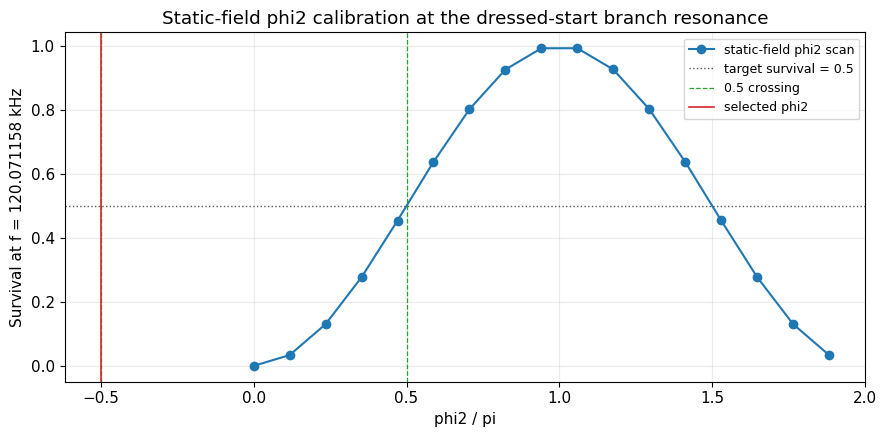

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(phi2_grid / np.pi, surv_phi2, "o-", color="tab:blue", label="static-field phi2 scan")
ax.axhline(TARGET_SURVIVAL, color="0.35", ls=":", lw=1.0, label="target survival = 0.5")
for idx, crossing in enumerate(crossings):
    ax.axvline(
        crossing / np.pi,
        color="tab:green",
        ls="--",
        lw=0.9,
        label="0.5 crossing" if idx == 0 else None,
    )
ax.axvline(phi2_working / np.pi, color="tab:red", lw=1.2, label="selected phi2")
ax.set_xlabel("phi2 / pi")
ax.set_ylabel(f"Survival at f = {F_BRANCH * 1e-3:.6f} kHz")
ax.set_title("Static-field phi2 calibration at the dressed-start branch resonance")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()

## 2. Wide frequency scan with the calibrated phase

Run the far-detuned frequency scan using the same static-field geometry and the calibrated `phi2` from the resonance scan above. This uses the same multiprocessing V3b helper path as the existing notebook.

In [10]:
offsets = np.linspace(-FRINGES_WINDOW, FRINGES_WINDOW, N_FREQ)
freqs = F_BRANCH + offsets * FRINGE_HZ
far = _load_valid_cache(FAR_CACHE, FAR_CACHE_VERSION)

if far is not None:
    cached_phi2 = float(far.get("phi2_working", np.nan))
    cached_center = float(far.get("center_frequency", np.nan))
    if not np.isclose(cached_phi2, phi2_working, atol=1e-8):
        print("Cached far scan uses a different phi2 working point; recomputing.")
        far = None
    elif not np.isclose(cached_center, F_BRANCH, atol=1e-8):
        print("Cached far scan uses a different center frequency; recomputing.")
        far = None

if far is not None:
    print(f"Loading cached static-field far scan: {FAR_CACHE.name}")
else:
    print(
        f"Computing static-field far scan ({N_FREQ} points, +/-{FRINGES_WINDOW:.0f} fringes) "
        f"around {F_BRANCH * 1e-3:.6f} kHz with {N_WORKERS} workers "
        f"at phi2 = {phi2_working / np.pi:.4f} pi..."
    )
    t0 = time.perf_counter()
    survival, elapsed_s, n_steps = run_frequency_scan_with_phases(
        freqs,
        velocity=MEAN_VELOCITY,
        phi1=PHI1,
        phi2=phi2_working,
        K=K,
        basis_dt_us=BASIS_DT_US,
        n_workers=N_WORKERS,
        dc_profile="static",
        static_e_field=STATIC_E_FIELD,
        initial_state_mode=INITIAL_STATE_MODE,
    )
    wall_s = time.perf_counter() - t0
    far = {
        "cache_version": np.int64(FAR_CACHE_VERSION),
        "freqs": np.asarray(freqs),
        "offsets": np.asarray(offsets),
        "survival": np.asarray(survival),
        "phi2_working": np.float64(phi2_working),
        "phi2_crossings": np.asarray(crossings, dtype=np.float64),
        "phase_diff": np.float64(phase_diff),
        "mean_velocity": np.float64(MEAN_VELOCITY),
        "static_e_field": np.float64(STATIC_E_FIELD),
        "fringe_hz": np.float64(FRINGE_HZ),
        "center_frequency": np.float64(F_BRANCH),
        "reference_frequency": np.float64(REFERENCE_F_RES),
        "K": np.int64(K),
        "basis_dt_us": np.float64(BASIS_DT_US),
        "n_workers": np.int64(N_WORKERS),
        "n_steps": np.int64(n_steps),
        "elapsed_s": np.float64(elapsed_s),
        "wall_s": np.float64(wall_s),
    }
    FAR_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(FAR_CACHE, **far)
    print(f"Done in {elapsed_s / 60:.2f} min, saved {FAR_CACHE.name}")

freqs = np.asarray(far["freqs"], dtype=float)
offsets = np.asarray(far["offsets"], dtype=float)
survival = np.asarray(far["survival"], dtype=float)
excitation = 1.0 - survival
fringe_hz = float(far["fringe_hz"])

Computing static-field far scan (161 points, +/-10 fringes) around 120.071158 kHz with 8 workers at phi2 = -0.5000 pi...
Done in 17.92 min, saved static30kv_far_frequency_scan_branch_resonance_k24_basis10_v2.npz


In [12]:
i_res = int(np.argmin(np.abs(freqs - F_BRANCH)))
summary = {
    "points": len(freqs),
    "static_e_field_kV_cm": float(STATIC_E_FIELD * 1e-3),
    "reference_frequency_kHz": float(REFERENCE_F_RES * 1e-3),
    "branch_frequency_kHz": float(F_BRANCH * 1e-3),
    "branch_shift_hz": float(branch_info["shift_hz"]),
    "phase_diff_over_pi": float(phase_diff / np.pi),
    "phi2_working_over_pi": float(phi2_working / np.pi),
    "survival_at_branch_resonance": float(survival[i_res]),
    "survival_min": float(survival.min()),
    "survival_max": float(survival.max()),
    "excitation_max": float(excitation.max()),
    "elapsed_min": float(far["elapsed_s"]) / 60.0,
    "n_steps": int(far["n_steps"]),
}
summary

{'points': 161,
 'static_e_field_kV_cm': 30.0,
 'reference_frequency_kHz': 119.64,
 'branch_frequency_kHz': 120.07115834855276,
 'branch_shift_hz': 431.1583485527517,
 'phase_diff_over_pi': -0.4999626710839581,
 'phi2_working_over_pi': -0.4999626710839581,
 'survival_at_branch_resonance': 0.5003977713411686,
 'survival_min': 0.00080673213565829,
 'survival_max': 0.9999953050232437,
 'excitation_max': 0.9991932678643417,
 'elapsed_min': 17.91804329000103,
 'n_steps': 117889}

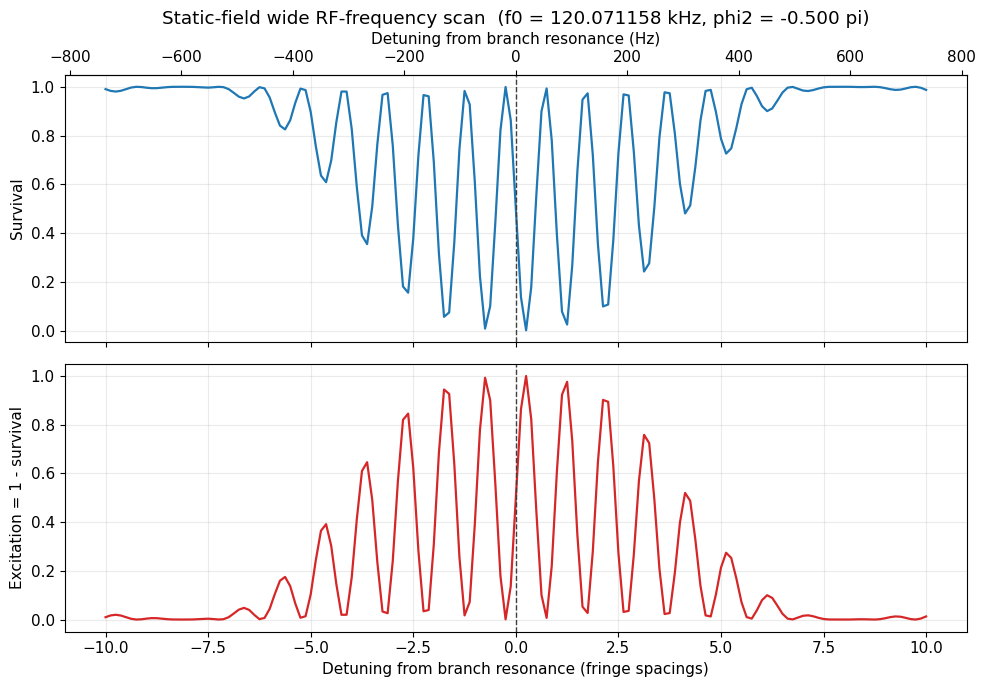

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(offsets, survival, color="tab:blue", lw=1.6)
axes[0].axvline(0, color="0.25", lw=1.0, ls="--")
axes[0].set_ylabel("Survival")
axes[0].set_title(
    f"Static-field wide RF-frequency scan  (f0 = {F_BRANCH * 1e-3:.6f} kHz, phi2 = {phi2_working / np.pi:.3f} pi)"
)

axes[1].plot(offsets, excitation, color="tab:red", lw=1.6)
axes[1].axvline(0, color="0.25", lw=1.0, ls="--")
axes[1].set_xlabel("Detuning from branch resonance (fringe spacings)")
axes[1].set_ylabel("Excitation = 1 - survival")

top = axes[0].secondary_xaxis(
    "top",
    functions=(lambda x: x * fringe_hz, lambda x: x / fringe_hz),
)
top.set_xlabel("Detuning from branch resonance (Hz)")

fig.tight_layout()

In [14]:
central = np.abs(offsets) <= 2
outer = np.abs(offsets) >= 8

print(f"Reference F_RES             = {REFERENCE_F_RES * 1e-3:.6f} kHz")
print(f"Branch resonance            = {F_BRANCH * 1e-3:.6f} kHz")
print(f"Shift from reference        = {branch_info['shift_hz']:+.6f} Hz")
print(f"Selected phi2 (absolute)    = {phi2_working / np.pi:.6f} pi")
print(f"Selected phase diff phi2-phi1 = {phase_diff / np.pi:+.6f} pi")
print(f"Branch-resonance survival   = {survival[i_res]:.6f}")
print(f"Central |offset| <= 2 fringes: excitation max = {excitation[central].max():.6f}")
print(f"Outer   |offset| >= 8 fringes: excitation max = {excitation[outer].max():.6f}")
print(f"Outer   |offset| >= 8 fringes: excitation min = {excitation[outer].min():.6f}")
print(f"Far scan elapsed = {float(far['elapsed_s']) / 60:.2f} min")

Reference F_RES             = 119.640000 kHz
Branch resonance            = 120.071158 kHz
Shift from reference        = +431.158349 Hz
Selected phi2 (absolute)    = -0.499963 pi
Selected phase diff phi2-phi1 = -0.499963 pi
Branch-resonance survival   = 0.500398
Central |offset| <= 2 fringes: excitation max = 0.999193
Outer   |offset| >= 8 fringes: excitation max = 0.019593
Outer   |offset| >= 8 fringes: excitation min = 0.000005
Far scan elapsed = 17.92 min


The important output of this notebook is the **calibrated static-field coil phase** printed above. That is the actual simulator phase difference to use for this constant-`30 kV/cm` geometry if the goal is a 50/50 final-state split at resonance in this two-pulse Ramsey sequence.